# HRL Training Analysis & Visualization

This notebook visualizes the training dynamics of the Hierarchical RL agent:
- **Reward evolution** (manager, worker, alignment)
- **PPO metrics** (loss, entropy, importance ratio)
- **Portfolio performance** during training
- **Policy convergence** indicators (alpha decay, replay buffer)
- **Out-of-sample evaluation** results

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# Paths — auto-detect latest run
LOGS_DIR = "logs"
RESULTS_BASE = "results"

# Find the latest results subfolder (datetime-named)
result_dirs = sorted([d for d in os.listdir(RESULTS_BASE)
                      if os.path.isdir(os.path.join(RESULTS_BASE, d))])
RESULTS_DIR = os.path.join(RESULTS_BASE, result_dirs[-1]) if result_dirs else RESULTS_BASE
print(f"Results dir: {RESULTS_DIR}")

# Find the latest TB log directory
tb_dirs = sorted([d for d in os.listdir(LOGS_DIR) if os.path.isdir(os.path.join(LOGS_DIR, d))])
TB_LOG_DIR = os.path.join(LOGS_DIR, tb_dirs[-1]) if tb_dirs else LOGS_DIR
print(f"TensorBoard logs: {TB_LOG_DIR}")

Results dir: results\20260506_190548
TensorBoard logs: logs\hrl_new_demo_20260506_190548


In [2]:
# Load TensorBoard events
ea = EventAccumulator(TB_LOG_DIR)
ea.Reload()

available_tags = ea.Tags()['scalars']
print(f"Available metrics ({len(available_tags)}):")
for tag in sorted(available_tags):
    print(f"  - {tag}")

Available metrics (12):
  - alpha/alpha_t
  - portfolio/return_pct
  - portfolio/value
  - ppo/entropy
  - ppo/loss
  - ppo/ratio
  - reward/alignment_mean
  - reward/manager_episode
  - reward/worker_episode
  - training/episodes
  - training/timesteps
  - worker/replay_buffer_size


In [3]:
def get_tb_data(tag):
    """Extract (step, value) from TensorBoard for a given tag."""
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return np.array(steps), np.array(values)


def smooth(values, weight=0.8):
    """Exponential moving average for smoothing noisy curves."""
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * weight + (1 - weight) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return np.array(smoothed)

## 1. Reward Evolution

How the rewards evolve across training episodes for both manager and worker.

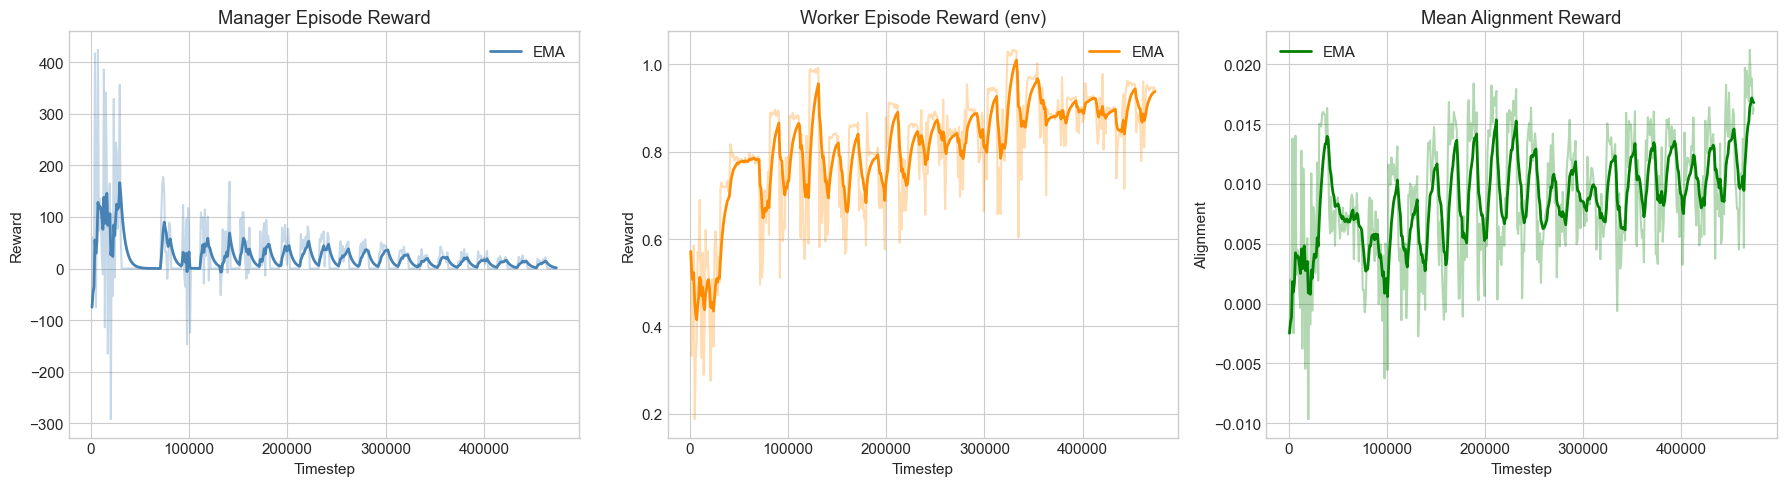

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Manager reward
steps, vals = get_tb_data('reward/manager_episode')
axes[0].plot(steps, vals, alpha=0.3, color='steelblue')
axes[0].plot(steps, smooth(vals), color='steelblue', linewidth=2, label='EMA')
axes[0].set_title('Manager Episode Reward')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Reward')
axes[0].legend()

# Worker (env) reward
steps, vals = get_tb_data('reward/worker_episode')
axes[1].plot(steps, vals, alpha=0.3, color='darkorange')
axes[1].plot(steps, smooth(vals), color='darkorange', linewidth=2, label='EMA')
axes[1].set_title('Worker Episode Reward (env)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Reward')
axes[1].legend()

# Alignment reward
if 'reward/alignment_mean' in available_tags:
    steps, vals = get_tb_data('reward/alignment_mean')
    axes[2].plot(steps, vals, alpha=0.3, color='green')
    axes[2].plot(steps, smooth(vals), color='green', linewidth=2, label='EMA')
    axes[2].set_title('Mean Alignment Reward')
    axes[2].set_xlabel('Timestep')
    axes[2].set_ylabel('Alignment')
    axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'reward_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. PPO Manager Metrics

Key indicators of the manager's PPO training:
- **Loss**: Should decrease and stabilize
- **Entropy**: High = exploration, Low = exploitation (should decrease gradually)
- **Importance ratio**: Should stay close to 1.0 (clipped PPO)

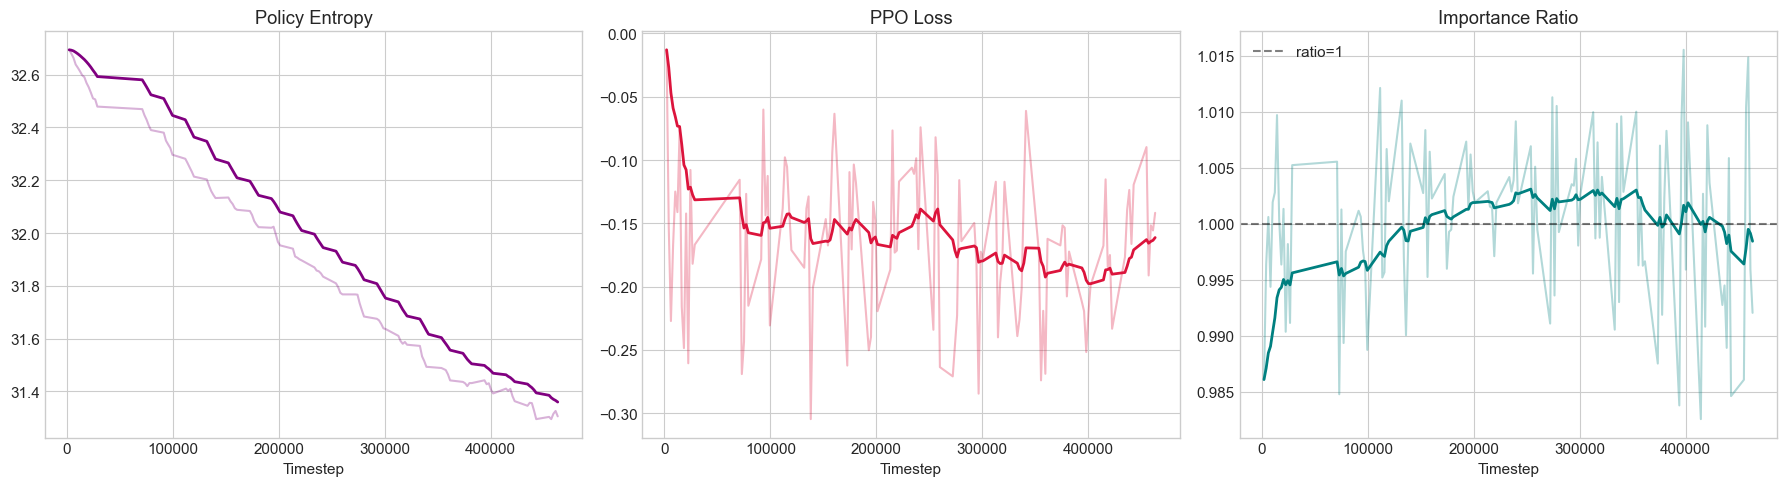

In [5]:
ppo_tags = [t for t in available_tags if t.startswith('ppo/')]

if ppo_tags:
    fig, axes = plt.subplots(1, len(ppo_tags), figsize=(6 * len(ppo_tags), 5))
    if len(ppo_tags) == 1:
        axes = [axes]

    colors = {'ppo/loss': 'crimson', 'ppo/entropy': 'purple', 'ppo/ratio': 'teal'}
    titles = {'ppo/loss': 'PPO Loss', 'ppo/entropy': 'Policy Entropy', 'ppo/ratio': 'Importance Ratio'}

    for ax, tag in zip(axes, sorted(ppo_tags)):
        steps, vals = get_tb_data(tag)
        color = colors.get(tag, 'gray')
        ax.plot(steps, vals, alpha=0.3, color=color)
        ax.plot(steps, smooth(vals, 0.9), color=color, linewidth=2)
        ax.set_title(titles.get(tag, tag))
        ax.set_xlabel('Timestep')
        if tag == 'ppo/ratio':
            ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='ratio=1')
            ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'ppo_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No PPO metrics found (manager was frozen the entire run?)")

## 3. Portfolio Performance During Training

Shows the portfolio value and return % at the end of each training episode.

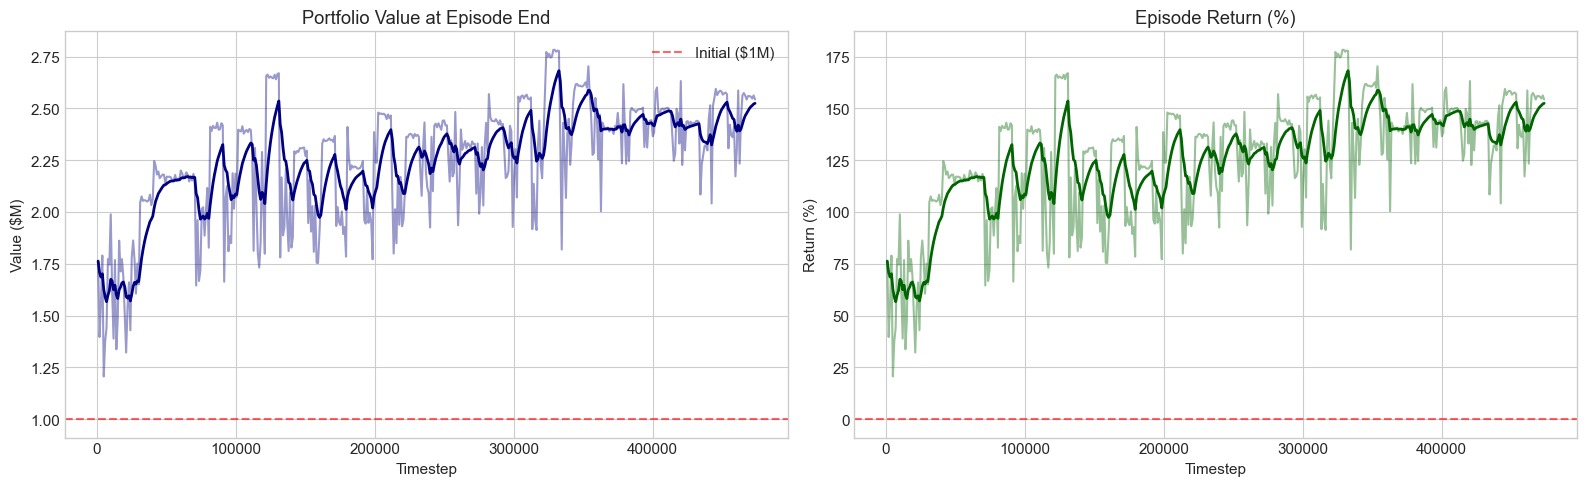

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Portfolio value
steps, vals = get_tb_data('portfolio/value')
axes[0].plot(steps, vals / 1e6, alpha=0.4, color='navy')
axes[0].plot(steps, smooth(vals / 1e6, 0.85), color='navy', linewidth=2)
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.6, label='Initial ($1M)')
axes[0].set_title('Portfolio Value at Episode End')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Value ($M)')
axes[0].legend()

# Portfolio return %
steps, vals = get_tb_data('portfolio/return_pct')
axes[1].plot(steps, vals, alpha=0.4, color='darkgreen')
axes[1].plot(steps, smooth(vals, 0.85), color='darkgreen', linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Episode Return (%)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'portfolio_training.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Policy Convergence Indicators

- **Alpha decay**: Controls the mix between alignment reward and env reward for the manager
- **Replay buffer size**: How many transitions the worker has to learn from

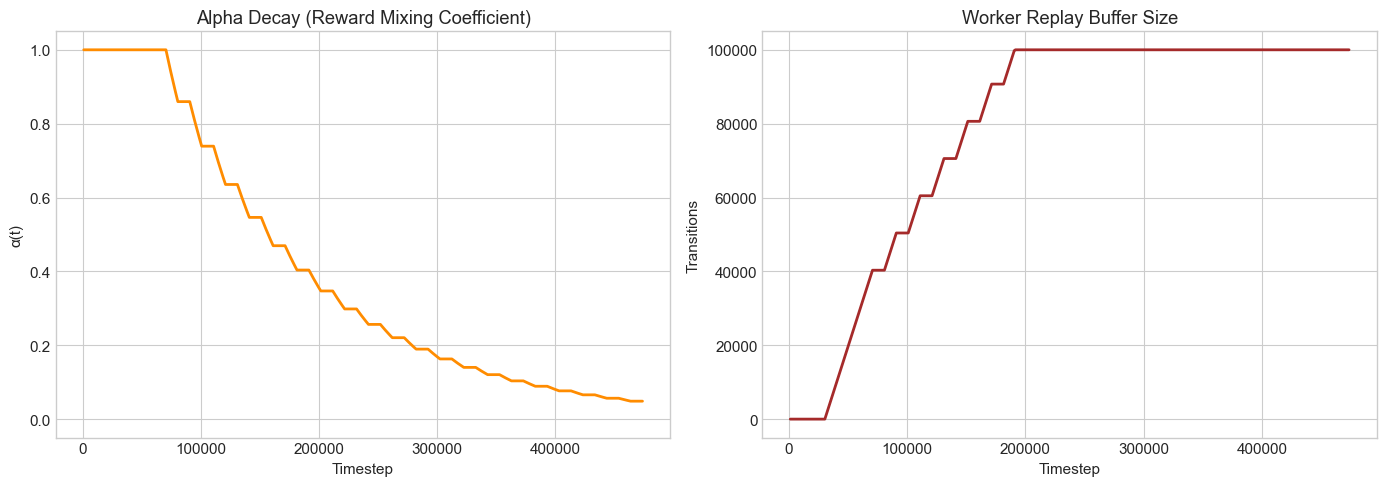

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alpha
if 'alpha/alpha_t' in available_tags:
    steps, vals = get_tb_data('alpha/alpha_t')
    axes[0].plot(steps, vals, color='darkorange', linewidth=2)
    axes[0].set_title('Alpha Decay (Reward Mixing Coefficient)')
    axes[0].set_xlabel('Timestep')
    axes[0].set_ylabel('α(t)')
    axes[0].set_ylim(-0.05, 1.05)

# Replay buffer
if 'worker/replay_buffer_size' in available_tags:
    steps, vals = get_tb_data('worker/replay_buffer_size')
    axes[1].plot(steps, vals, color='brown', linewidth=2)
    axes[1].set_title('Worker Replay Buffer Size')
    axes[1].set_xlabel('Timestep')
    axes[1].set_ylabel('Transitions')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'convergence_indicators.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Training Phase Analysis

Visualizes the saw-tooth pattern of Phase 3 (alternating manager/worker training).

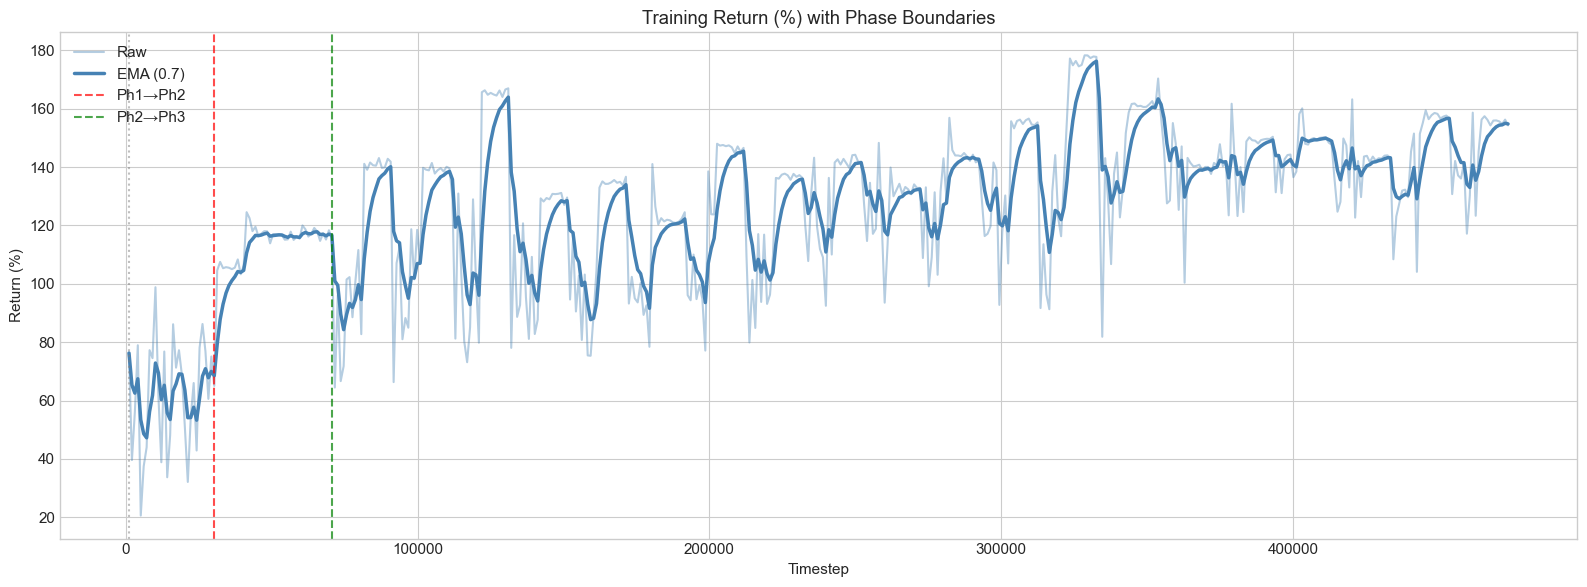

In [8]:
steps_r, reward_vals = get_tb_data('reward/worker_episode')
steps_p, portfolio_vals = get_tb_data('portfolio/return_pct')

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(steps_p, portfolio_vals, alpha=0.4, color='steelblue', label='Raw')
ax.plot(steps_p, smooth(portfolio_vals, 0.7), color='steelblue', linewidth=2.5, label='EMA (0.7)')

# Annotate phases (approximate)
if len(steps_p) > 0:
    total_steps = steps_p[-1]
    # These are approximate boundaries
    ax.axvline(x=steps_p[0], color='gray', linestyle=':', alpha=0.5)
    
    # Find approximate phase boundaries from training/episodes
    if 'training/episodes' in available_tags:
        ep_steps, ep_vals = get_tb_data('training/episodes')
        # Phase transitions happen at specific episode counts
        # Ph1 ends ~30 eps, Ph2 ends ~70 eps, Ph3 starts at ~70
        ph1_end_idx = np.searchsorted(ep_vals, 30)
        ph2_end_idx = np.searchsorted(ep_vals, 70)
        
        if ph1_end_idx < len(ep_steps):
            ax.axvline(x=ep_steps[ph1_end_idx], color='red', linestyle='--', alpha=0.7, label='Ph1→Ph2')
        if ph2_end_idx < len(ep_steps):
            ax.axvline(x=ep_steps[ph2_end_idx], color='green', linestyle='--', alpha=0.7, label='Ph2→Ph3')

ax.set_title('Training Return (%) with Phase Boundaries')
ax.set_xlabel('Timestep')
ax.set_ylabel('Return (%)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'phase_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Cycle-by-Cycle Performance

Shows how each alternating cycle improves (or not) over the previous one.

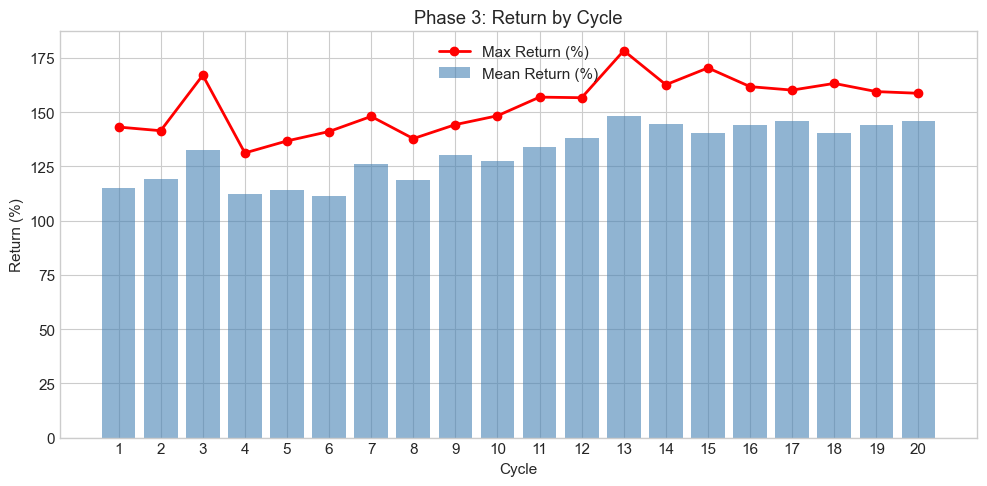

In [9]:
steps_p, portfolio_vals = get_tb_data('portfolio/return_pct')

# After Phase 1 (30 eps) + Phase 2 (40 eps) = 70 episodes
# Each cycle = 20 episodes (10 manager + 10 worker)
# Worker sub-phase episodes are the ones that matter for combined performance

if 'training/episodes' in available_tags:
    ep_steps, ep_vals = get_tb_data('training/episodes')
    
    # Get data starting from Phase 3 (episode > 70)
    ph3_mask = ep_vals > 70
    ph3_steps = ep_steps[ph3_mask]
    
    # Map back to portfolio returns at those steps
    ph3_returns = []
    for s in ph3_steps:
        idx = np.searchsorted(steps_p, s)
        if idx < len(portfolio_vals):
            ph3_returns.append(portfolio_vals[idx])
    
    if ph3_returns:
        ph3_returns = np.array(ph3_returns)
        ph3_episodes = ep_vals[ph3_mask][:len(ph3_returns)]
        
        # Group by cycle (20 eps each)
        cycle_starts = np.arange(71, ph3_episodes[-1], 20)
        cycle_means = []
        cycle_maxs = []
        
        for start in cycle_starts:
            mask = (ph3_episodes >= start) & (ph3_episodes < start + 20)
            if mask.any():
                cycle_means.append(ph3_returns[mask].mean())
                cycle_maxs.append(ph3_returns[mask].max())
        
        fig, ax = plt.subplots(figsize=(10, 5))
        cycles = range(1, len(cycle_means) + 1)
        ax.bar(cycles, cycle_means, alpha=0.6, color='steelblue', label='Mean Return (%)')
        ax.plot(cycles, cycle_maxs, 'ro-', linewidth=2, label='Max Return (%)')
        ax.set_title('Phase 3: Return by Cycle')
        ax.set_xlabel('Cycle')
        ax.set_ylabel('Return (%)')
        ax.legend()
        ax.set_xticks(list(cycles))
        
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'cycle_performance.png'), dpi=150, bbox_inches='tight')
        plt.show()

## 7. Out-of-Sample Results

Load the evaluation CSVs and plot portfolio evolution on validation and test sets.

In [10]:
# Load run summary
summary_path = os.path.join(RESULTS_DIR, 'run_summary_hrl_new.json')
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        summary = json.load(f)
    
    print("=" * 60)
    print(f"  Run: {summary['timestamp']}")
    print(f"  Training time: {summary['training_time_min']:.1f} min")
    print(f"  Total timesteps: {summary['total_timesteps']:,}")
    print(f"  Total episodes: {summary['episodes']}")
    print("=" * 60)
    
    # Print metrics table
    metrics_keys = list(summary['metrics'].keys())
    for period_name in metrics_keys:
        m = summary['metrics'][period_name]
        print(f"\n  {period_name.upper()}:")
        for k, v in m.items():
            print(f"    {k:.<30} {v}")
else:
    print(f"No summary found at {summary_path}. Run training first.")

  Run: 2026-05-06 23:21:19
  Training time: 254.9 min
  Total timesteps: 473,760
  Total episodes: 470

  VALIDATION:
    Final Balance ($)............. 858308.99
    Cumulative Return (%)......... -14.17
    Sharpe Ratio.................. -0.5182
    Diversification (%)........... 83.44
    Active Assets................. 126/151
    Max Drawdown (%).............. -23.16
    Annual Volatility (%)......... 24.12

  TEST_2023:
    Final Balance ($)............. 1223905.89
    Cumulative Return (%)......... 22.39
    Sharpe Ratio.................. 1.5741
    Diversification (%)........... 84.11
    Active Assets................. 127/151
    Max Drawdown (%).............. -12.98
    Annual Volatility (%)......... 13.58

  TEST_2024:
    Final Balance ($)............. 1269345.87
    Cumulative Return (%)......... 26.93
    Sharpe Ratio.................. 1.6258
    Diversification (%)........... 82.78
    Active Assets................. 125/151
    Max Drawdown (%).............. -9.26
    Ann

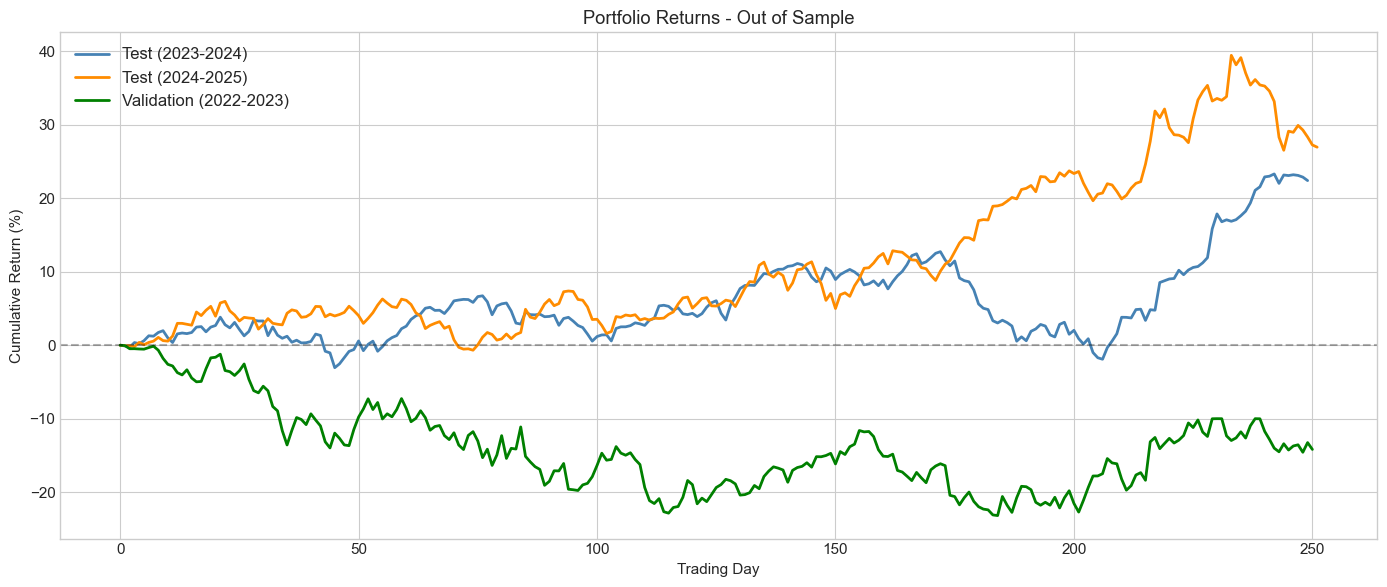

In [11]:
# Plot portfolio evolution for all evaluation periods
csv_files = [f for f in os.listdir(RESULTS_DIR) if f.startswith('cuenta_') and f.endswith('.csv')]

if csv_files:
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['steelblue', 'darkorange', 'green', 'crimson']
    
    for i, csv_file in enumerate(sorted(csv_files)):
        df = pd.read_csv(os.path.join(RESULTS_DIR, csv_file))
        label = csv_file.replace('cuenta_', '').replace('_HRL_new.csv', '').replace('_', ' ').title()
        
        # Normalize to show returns
        returns_pct = (df['account_value'] / df['account_value'].iloc[0] - 1) * 100
        ax.plot(returns_pct.values, linewidth=2, color=colors[i % len(colors)], label=label)
    
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_title('Portfolio Returns - Out of Sample')
    ax.set_xlabel('Trading Day')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'evaluation_results.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No evaluation CSVs found. Run training first.")

## 8. Convergence Diagnosis

Key questions to assess training health:
1. **Is reward still increasing?** → More cycles needed
2. **Is entropy too low?** → Policy may have collapsed
3. **Is alpha near 0?** → Manager uses mostly env reward (good for later phases)
4. **Is the saw-tooth amplitude decreasing?** → Convergence towards equilibrium

In [12]:
# Convergence diagnostic summary
print("\n" + "=" * 60)
print("  CONVERGENCE DIAGNOSIS")
print("=" * 60)

# 1. Is reward still improving?
steps_r, reward_vals = get_tb_data('portfolio/return_pct')
if len(reward_vals) > 20:
    last_20pct = reward_vals[int(len(reward_vals) * 0.8):]
    first_20pct = reward_vals[int(len(reward_vals) * 0.6):int(len(reward_vals) * 0.8)]
    trend = np.mean(last_20pct) - np.mean(first_20pct)
    if trend > 5:
        print(f"  [!] Return still improving (+{trend:.1f}% last vs previous 20%) → MORE CYCLES RECOMMENDED")
    elif trend > 0:
        print(f"  [~] Return improving slowly (+{trend:.1f}%) → Near convergence")
    else:
        print(f"  [✓] Return plateaued ({trend:.1f}%) → Likely converged")

# 2. Entropy check
if 'ppo/entropy' in available_tags:
    _, entropy_vals = get_tb_data('ppo/entropy')
    final_entropy = np.mean(entropy_vals[-10:])
    initial_entropy = np.mean(entropy_vals[:10])
    print(f"  Entropy: {initial_entropy:.4f} → {final_entropy:.4f}")
    if final_entropy < 0.1:
        print(f"  [!] Very low entropy → Policy may be too deterministic")
    elif final_entropy < initial_entropy * 0.3:
        print(f"  [~] Entropy dropped significantly → Normal exploitation phase")
    else:
        print(f"  [✓] Healthy entropy level")

# 3. Alpha state
if 'alpha/alpha_t' in available_tags:
    _, alpha_vals = get_tb_data('alpha/alpha_t')
    final_alpha = alpha_vals[-1]
    print(f"  Final α(t): {final_alpha:.4f}")
    if final_alpha < 0.1:
        print(f"  [✓] Manager mostly uses environment reward (aligned)")
    else:
        print(f"  [~] Manager still relies partly on alignment reward")

# 4. Saw-tooth amplitude
if len(reward_vals) > 40:
    # Compute rolling std in windows of 20 episodes
    window = 20
    early_std = np.std(reward_vals[70:70 + window]) if len(reward_vals) > 90 else 0
    late_std = np.std(reward_vals[-window:])
    print(f"  Volatility (early Ph3): {early_std:.1f}% | (late Ph3): {late_std:.1f}%")
    if late_std < early_std * 0.7:
        print(f"  [✓] Oscillations decreasing → Approaching equilibrium")
    else:
        print(f"  [~] Oscillations still present → Manager-worker still adapting")

print("=" * 60)


  CONVERGENCE DIAGNOSIS
  [~] Return improving slowly (+1.2%) → Near convergence
  Entropy: 32.6220 → 31.3228
  [✓] Healthy entropy level
  Final α(t): 0.0486
  [✓] Manager mostly uses environment reward (aligned)
  Volatility (early Ph3): 28.5% | (late Ph3): 12.6%
  [✓] Oscillations decreasing → Approaching equilibrium
